# What is Function?

```
Built in SQL code that:
    - accepts an input value
    - process it
    - returns an output value
```

# Why do you need Function?

```
To :
1. data manipulation
2. analyze data
3. clean data
4. transform data
```

# Categories of ROW FUNCTIONS

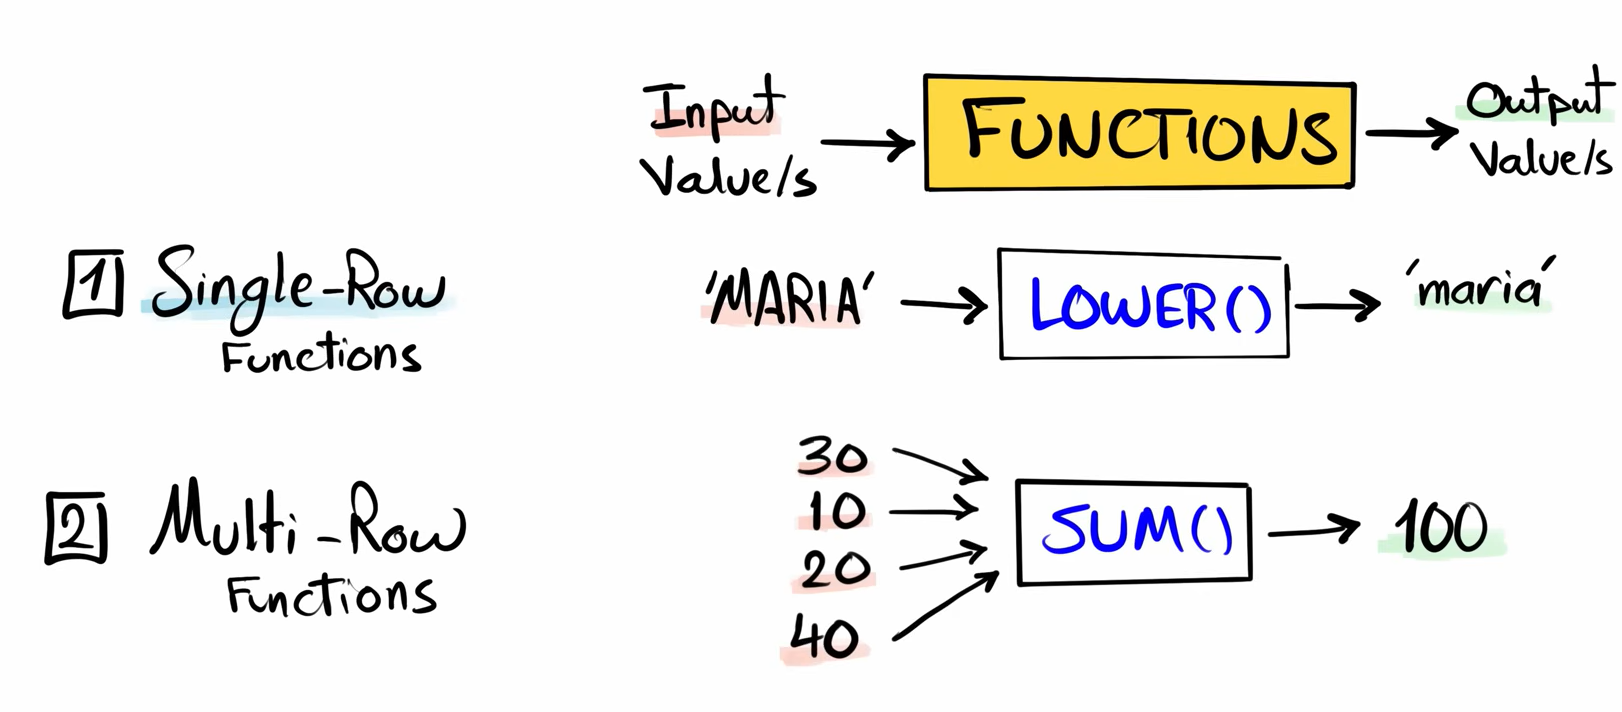

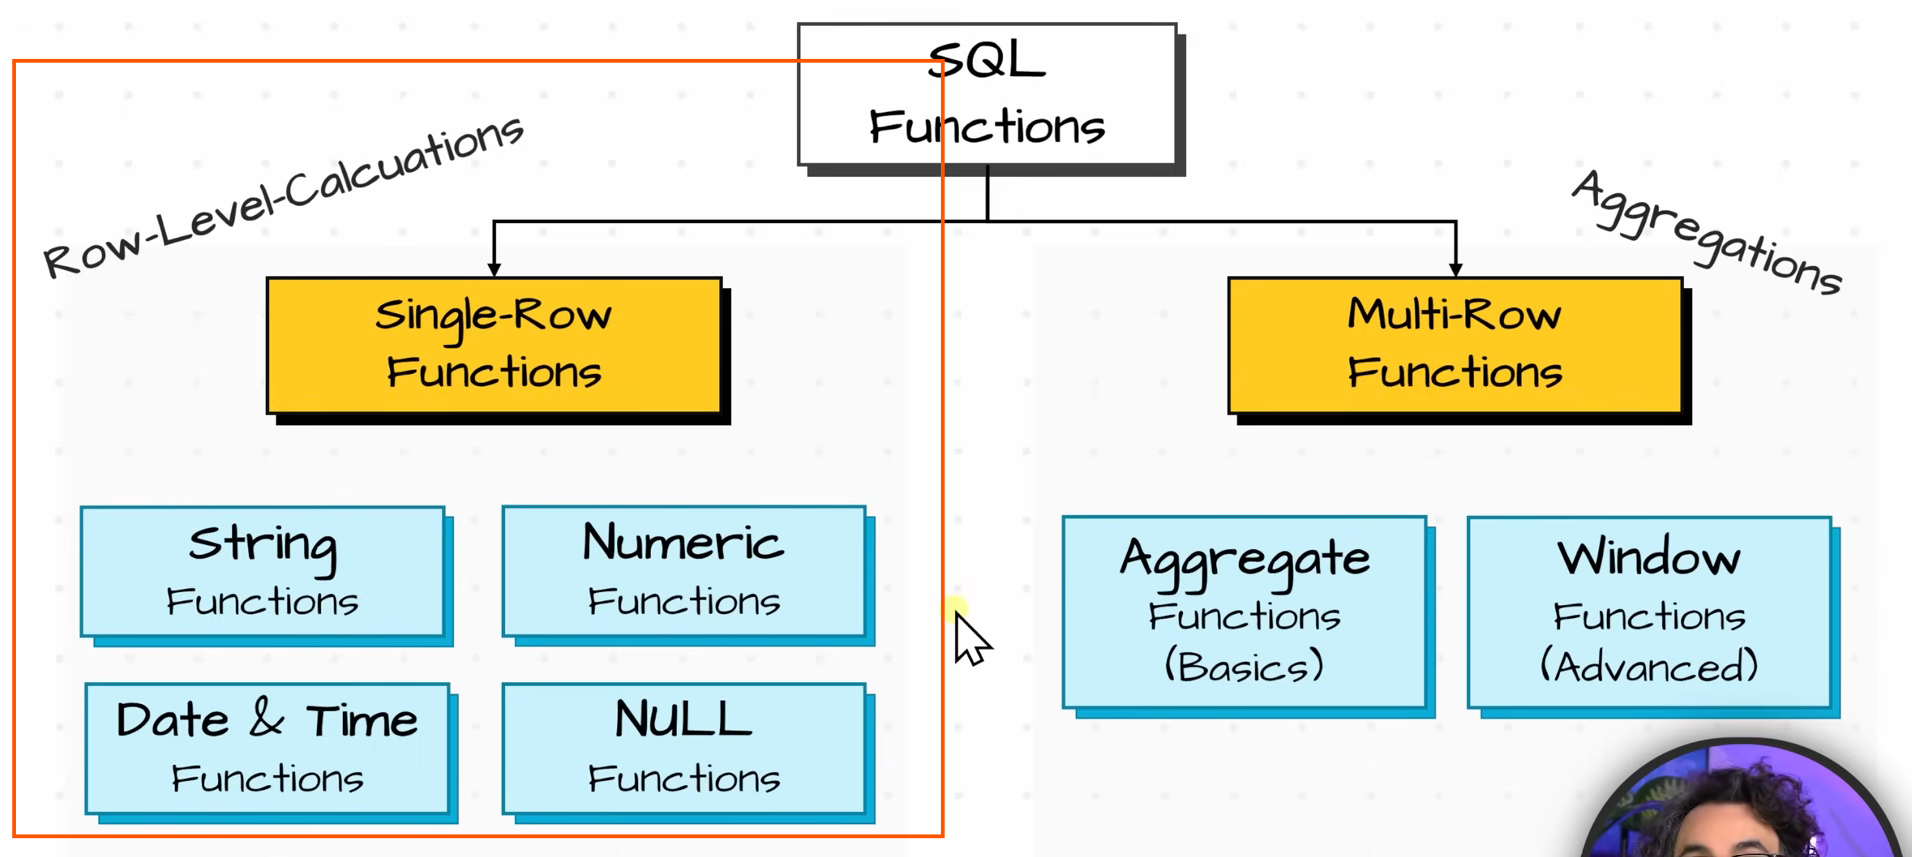

# Nested Function : Function used inside another function

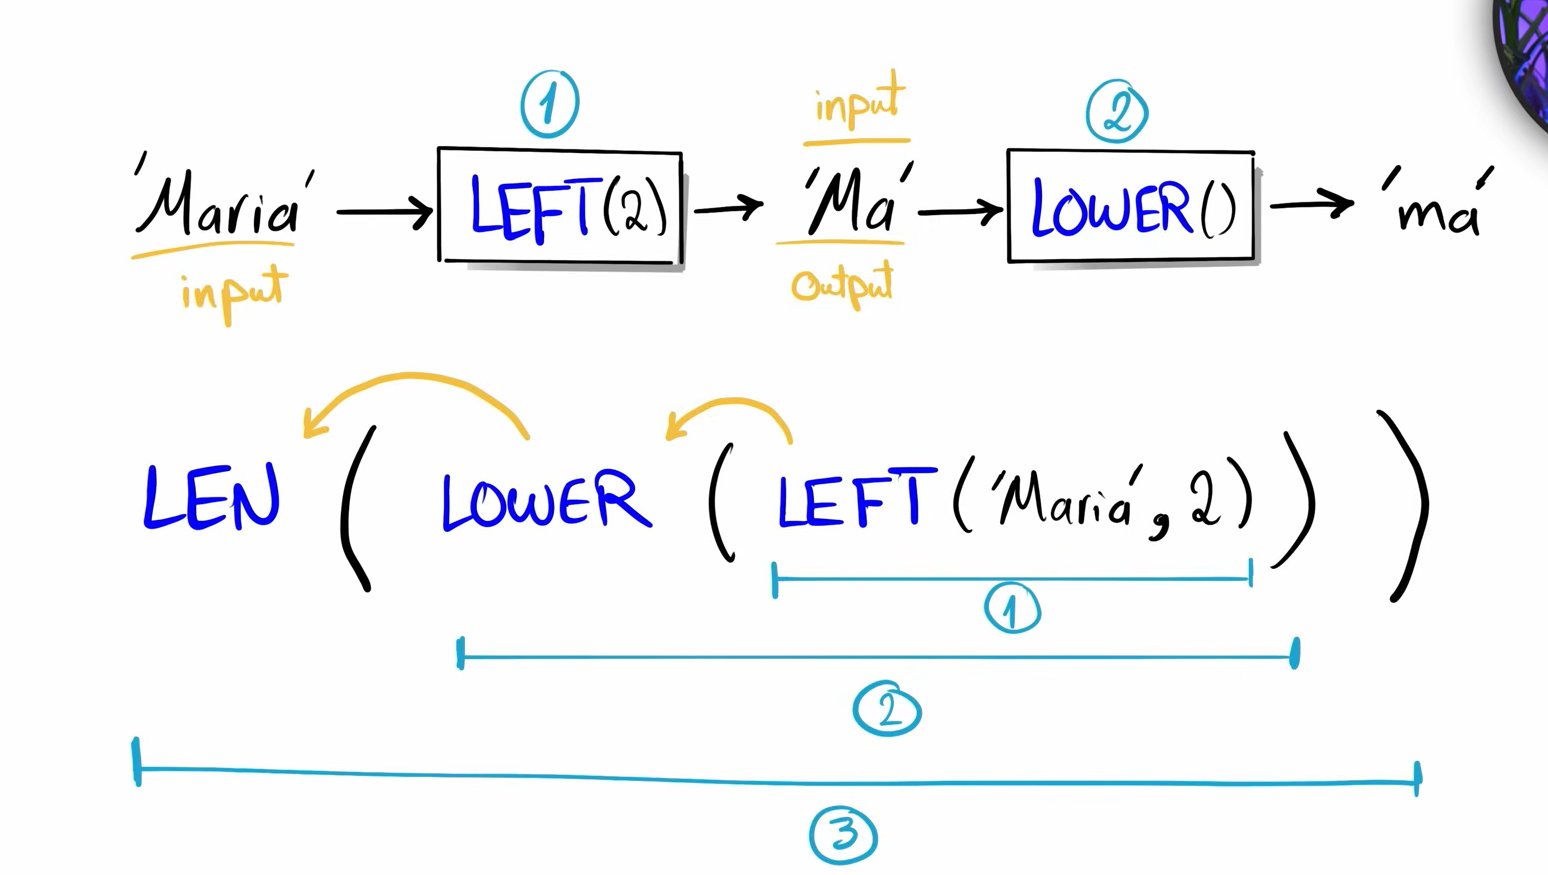

# Types of Functions

```
1. STRING FUNCTIONS : CONCAT, UPPER, LOWER, TRIM, REPLACE, LEN/LENGTH, LEFT, RIGHT, SUBSTRING
2. NUMBER FUNCTIONS : ROUND, ABS
3. DATE & TIME FUNCTIONS : 
4. NULL FUNCTIONS : 
5. CASE STATEMENT : 
```

## STRING FUNCTIONS : 

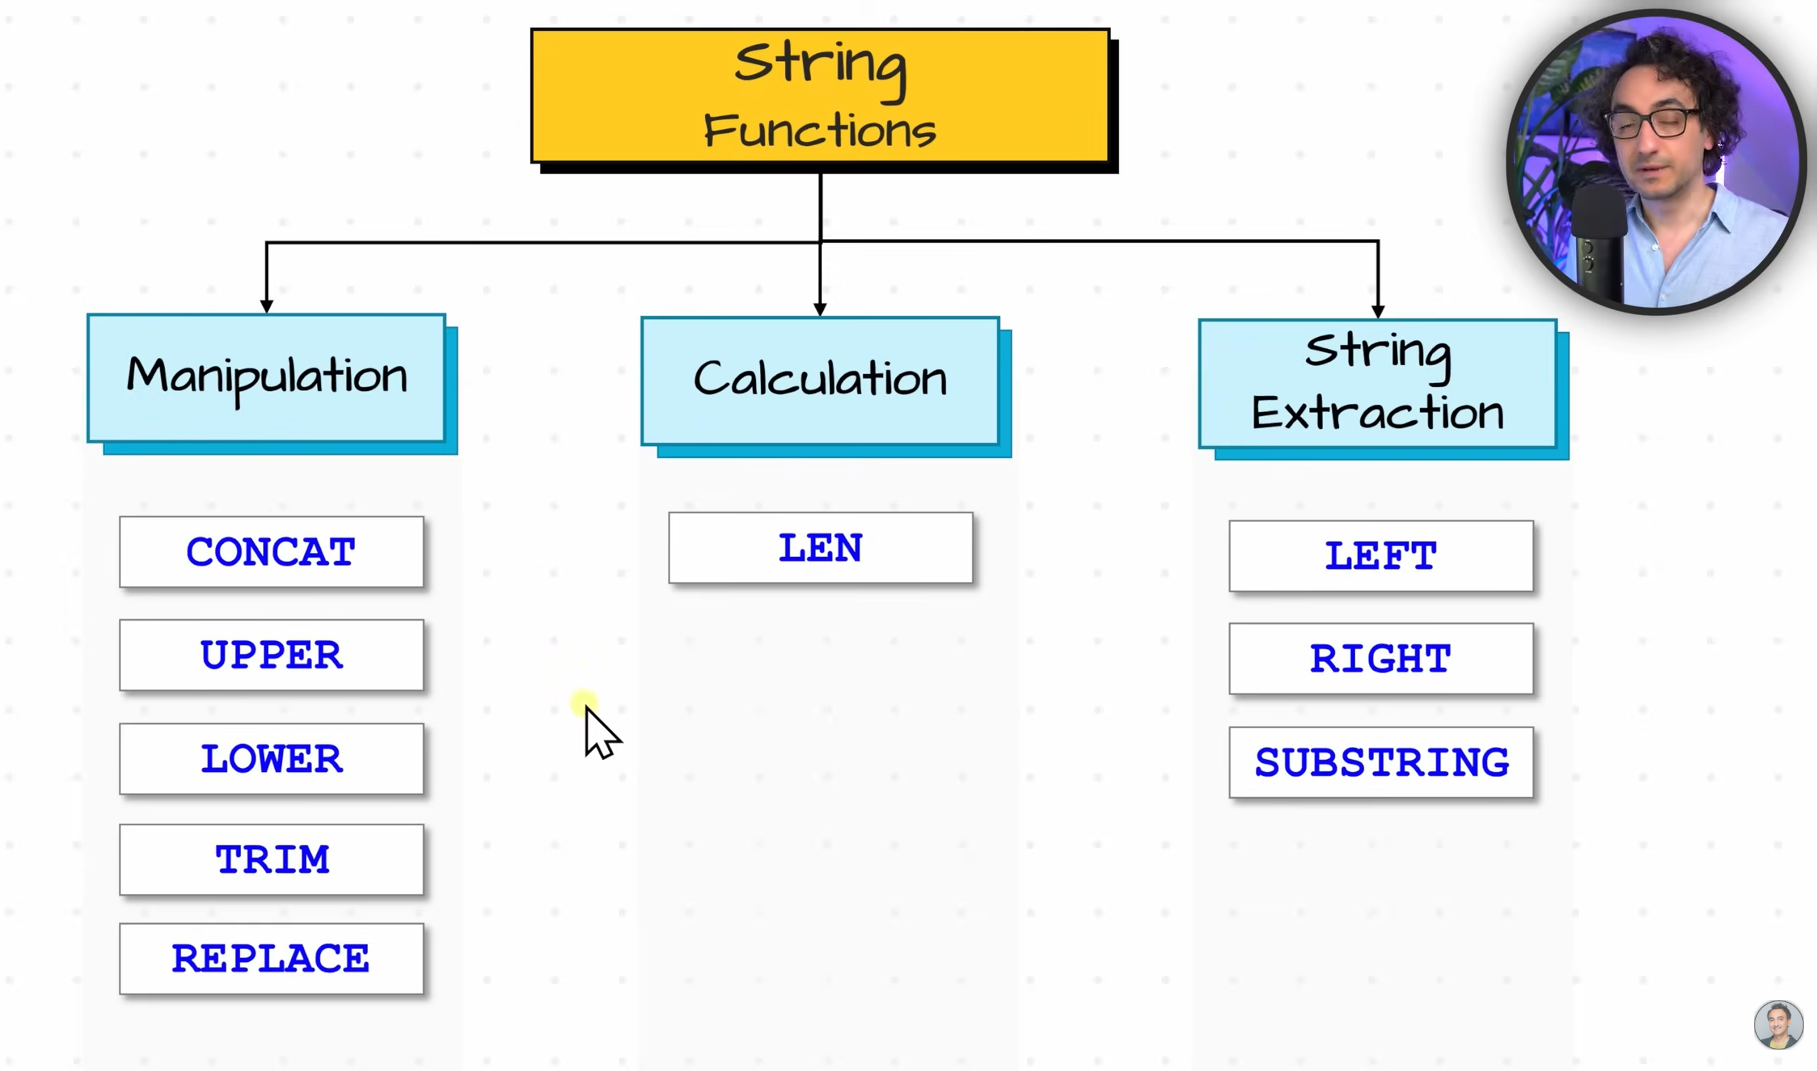

### CONCAT : Combine multiple string value in single string

#### Syntax : 
```
CONCAT('v1', 'v2', 'v3')
v1 can be value or column
```

#### Show the list of customers, concatenate first name and country into one column

In [7]:
%%sql
select concat(firstname, ' : ', country) as 'Name & Country' from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

Name & Country
Jossef : Germany
Kevin : USA
Mary : USA
Mark : Germany
Anna : USA


### UPPER & LOWER : 
```
UPPER : converts all characters to UPPERCASE
LOWER : converts all characters to LOWERCASE
```

#### Syntax :
```
UPPER('column/value')
LOWER('column/value')
```

#### Transform the customer's first name to lower case

In [2]:
%%sql
select firstname,
    lower(firstname) as SmallerFirstName
from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

firstname,SmallerFirstName
Jossef,jossef
Kevin,kevin
Mary,mary
Mark,mark
Anna,anna


#### Converts the first name into UPPER case.

In [3]:
%%sql
select firstname, UPPER(firstname) as CapitalFirstName from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

firstname,CapitalFirstName
Jossef,JOSSEF
Kevin,KEVIN
Mary,MARY
Mark,MARK
Anna,ANNA


### TRIM : Removes leading (as prefix) and traiing(as suffix) spaces from string value

#### Syntax :
```
TRIM('value/column')
```

#### Find customers whose first name contains leading and trailing spaces.

In [5]:
%%sql
use MyDatabase;

Running query in 'mysql+pymysql://'

++
||
++
++

##### Method 1:

In [10]:
%%sql
select first_name
from customers
where first_name != TRIM(first_name);

Running query in 'mysql+pymysql://'

1 rows affected.

first_name
John


##### Method 2:

In [20]:
%%sql
select first_name,
    length(first_name) as len_before,
    length(trim(first_name)) as len_after,
    (length(first_name) - length(trim(first_name))) as spaces
from customers;
-- where length(first_name) != length(trim(first_name));

Running query in 'mysql+pymysql://'

5 rows affected.

first_name,len_before,len_after,spaces
Maria,5,5,0
John,5,4,1
Georg,5,5,0
Martin,6,6,0
Peter,5,5,0


##### Method 3:

In [31]:
%%sql
select first_name
from customers
where first_name like '% '
    or first_name like ' %';

Running query in 'mysql+pymysql://'

1 rows affected.

first_name
John


### REPLACE : 
```
1. Replaces specific character with new character
2. Also works as REMOVE where you have to put new character value as empty
```

#### Syntax : 
```
REPLACE('value/column', 'old_replacing_value', 'new_replacement_value')
```

#### Remove dashes(-) from the given phone number : 123-456-7890

In [44]:
%%sql
select '123-456-7890' as phone_number,
replace ('123-456-7890', '-', ':') as updated_phone_number_REPLACED_,
replace ('123-456-7890', '-', '') as clean_phone_number_REMOVED_;

Running query in 'mysql+pymysql://'

1 rows affected.

phone_number,updated_phone_number_REPLACED_,clean_phone_number_REMOVED_
123-456-7890,123:456:7890,1234567890


#### Change the file extension of excel file instead of saved as txt files

In [45]:
%%sql
select 'report.txt' as old_file_name,
    replace('report.txt', '.txt', '.csv') as new_file_name;

Running query in 'mysql+pymysql://'

1 rows affected.

old_file_name,new_file_name
report.txt,report.csv


### LEN or LENGTH : Count the number of character in the value(string/int/date)

#### Syntax :
```
len('column/value')
length('column/value')
```

In [52]:
%%sql
select first_name, length(first_name), score, length(score) from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

first_name,length(first_name),score,length(score)
Maria,5,350,3
John,5,900,3
Georg,5,750,3
Martin,6,500,3
Peter,5,0,1


In [56]:
%%sql
select '2026-02-12' as Date, length('2026-02-12') as date_length;

Running query in 'mysql+pymysql://'

1 rows affected.

Date,date_length
2026-02-12,10


### LEFT & RIGHT :
```
1. String Extraction function.
2. LEFT : Extracts specific number of characters from the starts
3. RIGHT : Extracts specific number of characters from the end or last 
```

#### Syntax :
```
LEFT : LEFT('value/column', no._of_characters_from_start)
RIGHT : RIGHT('value/column', no._of_characters_from_END)
```

#### Retrieve the first two character from first name of each customers.

In [60]:
%%sql
select first_name,
    left(trim(first_name), 2) as fist_2_char
from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

first_name,fist_2_char
Maria,Ma
John,Jo
Georg,Ge
Martin,Ma
Peter,Pe


#### Retrieve the last two character of first name of each customers.

In [63]:
%%sql
select first_name,
    right(first_name, 2) as last_2_char
from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

first_name,last_2_char
Maria,ia
John,hn
Georg,rg
Martin,in
Peter,er


### SUBSTRING : Extract a part of string at a specified position

#### Syntax : 
```
SUBSTRING('string/value', start_position, end position)
```

#### Retrieve a list of customer's first name after removing the first character.

In [68]:
%%sql
select first_name,
    substring(trim(first_name), 2) as without_first_char
from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

first_name,without_first_char
Maria,aria
John,ohn
Georg,eorg
Martin,artin
Peter,eter


## NUMERIC FUNCTIONS :

### ROUND Function : It round the number 

#### Syntax :
```
ROUND('number/value/column', rounding_decimal_place)
```

#### Round the number 3.516 till 2 decimal place, 1 decimal place, 0 decimal place

In [69]:
%%sql
select 3.516 as number,
    round(3.516, 2) as round_2,
    round(3.516, 1) as round_1,
    round(3.516) as round_0;

Running query in 'mysql+pymysql://'

1 rows affected.

number,round_2,round_1,round_0
3.516,3.52,3.5,4


### ABS (Absolute) Function : returns the positive(absolute) value of the number, removing any negative sign

#### Syntax :
```
ABS(value/column)
```

#### convert the -10 in positive.

In [70]:
%%sql
select -10 as number,
    ABS(-10) as positive_number;

Running query in 'mysql+pymysql://'

1 rows affected.

number,positive_number
-10,10


#### What will be absolute of 33?

In [71]:
%%sql
select 33 as number,
    ABS(33) as ABS_OF_33;

Running query in 'mysql+pymysql://'

1 rows affected.

number,ABS_OF_33
33,33


## DATE & TIME FUNCTIONS : 

### Datetime or Timestamp

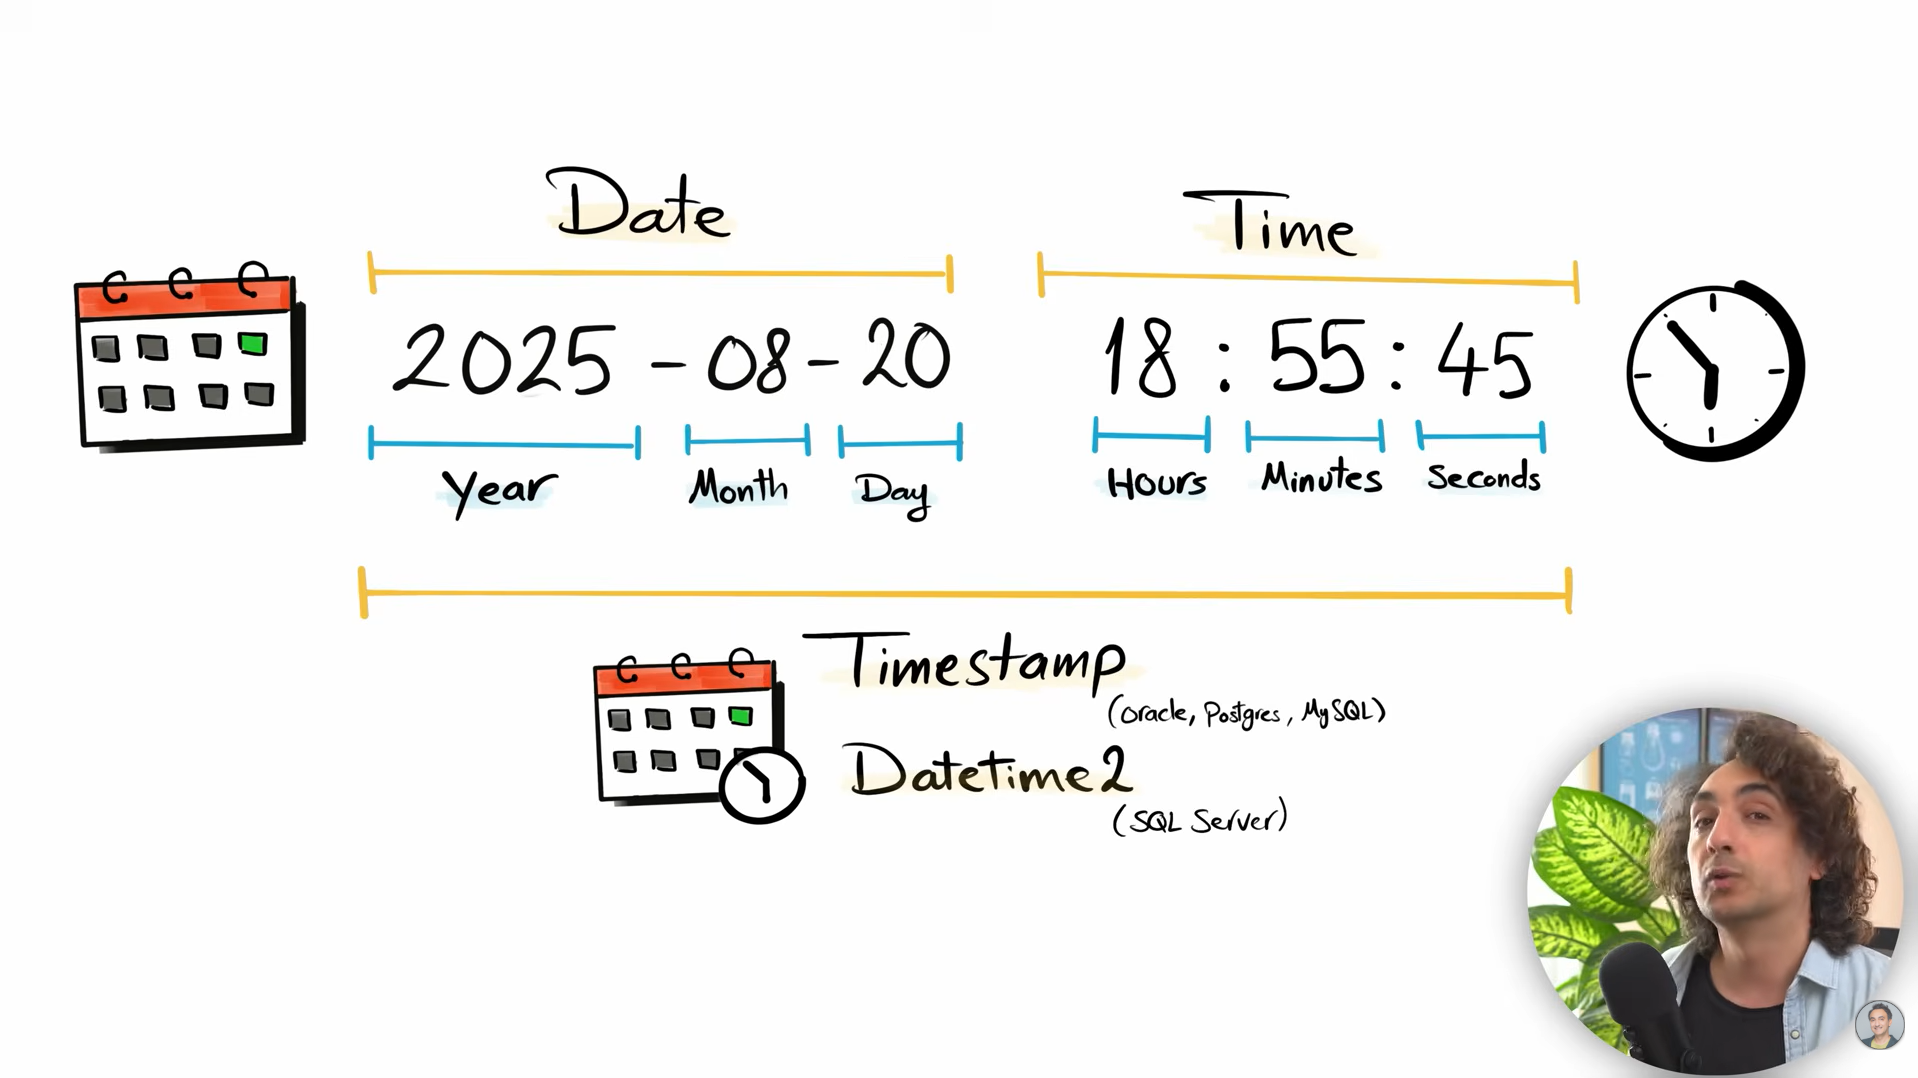

### Syntax : 
```
1. now() / getdate()
2. DATE_ADD()
3. DATE_ADD(now(), INTERVAL '5:30' HOUR MINUTE)  -- to add time in time to update zone or etc..
4. DAY(date)
5. MONTH(date)
6. YEAR(date)
7. DATEPART(part, date) : It extract the date part of the date like (Year, Quarter, Month, Week, Hours, Minutes, Seconds) (Oracle/PostgreSQL)
 . EXTRACT(part from date) : same as DATEPART : Extract many things from this keyword or function
8. DATENAME(part, date) {MONTHNAME(date), DAYNAME(date)} : Returns the name to a datepart
9. DATETRUNC(part, date) {DATE_FORMAT(date, '%Y-%m-%d %H-%i-%s')} : reset the level of timestamp
10. EOMONTH(date) {LAST_DAY(date)}: Returns the last day of the month
```

### Source of DATE value:

```
1. Column Date Data : It is from any table
1. HARD CODED Date Data : It is a static value
3. NOW()(MySQL)/GETDATE()(Oracle/MSSQL/etc..) : Returns the current date and time at the moment when the query is executed
```

#### Example :

In [84]:
%%sql
select orderdate as TableDate_orderdate,
    '2022-08-12' as HardCodedDate,
    now() as todayGMT,
    DATE_ADD(now(), INTERVAL '5:30' HOUR_MINUTE) as todayIST
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

TableDate_orderdate,HardCodedDate,todayGMT,todayIST
2025-01-01,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-01-05,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-01-10,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-01-20,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-02-01,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-02-05,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-02-15,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-02-18,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-03-10,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22
2025-03-15,2022-08-12,2026-07-10 06:12:22,2026-07-10 11:42:22


### Date & Time Function Overview : 

#### Part Extraction : (DAY, MONTH, YEAR, DATEPART / EXTRACT, DATENAME, DATETRUNC, EOMONTH)

##### DAY, MONTH, YEAR

```
DAY() : returns the DAY from a date
MONTH() : returns the MONTH from a date
YEAR() : returns the YEAR from a date
```

In [4]:
%%sql
select orderid,
    creationtime,
    year(creationtime) as Year,
    month(creationtime) as Month,
    day(creationtime) as Day
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,Year,Month,Day
1,2025-01-01 12:34:56,2025,1,1
2,2025-01-05 23:22:04,2025,1,5
3,2025-01-10 18:24:08,2025,1,10
4,2025-01-20 05:50:33,2025,1,20
5,2025-02-01 14:02:41,2025,2,1
6,2025-02-06 15:34:57,2025,2,6
7,2025-02-16 06:22:01,2025,2,16
8,2025-02-18 10:45:22,2025,2,18
9,2025-03-10 12:59:04,2025,3,10
10,2025-03-16 23:25:15,2025,3,16


##### DATEPART / EXTRACT

```
DATEPART(Year, date)
EXTRACT(Year from date)
```

In [21]:
%%sql
SELECT orderid,
    creationtime,
    Extract(
        Year
        from creationtime
    ) AS Year,
    EXTRACT(
        Quarter
        from creationtime
    ) as Quarter,
    Extract(
        Week
        from creationtime
    ) as Week,
    Extract(
        Month
        from creationtime
    ) as Month,
    Extract(
        Day
        from creationtime
    ) as Day,
    Extract(
        Hour
        from creationtime
    ) as Hour,
    Extract(
        Minute
        from creationtime
    ) as Minutes,
    Extract(
        second
        from creationtime
    ) as Seconds
FROM orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,Year,Quarter,Week,Month,Day,Hour,Minutes,Seconds
1,2025-01-01 12:34:56,2025,1,0,1,1,12,34,56
2,2025-01-05 23:22:04,2025,1,1,1,5,23,22,4
3,2025-01-10 18:24:08,2025,1,1,1,10,18,24,8
4,2025-01-20 05:50:33,2025,1,3,1,20,5,50,33
5,2025-02-01 14:02:41,2025,1,4,2,1,14,2,41
6,2025-02-06 15:34:57,2025,1,5,2,6,15,34,57
7,2025-02-16 06:22:01,2025,1,7,2,16,6,22,1
8,2025-02-18 10:45:22,2025,1,7,2,18,10,45,22
9,2025-03-10 12:59:04,2025,1,10,3,10,12,59,4
10,2025-03-16 23:25:15,2025,1,11,3,16,23,25,15


##### DATENAME , MONTHNAME, DAYNAME

```
DATENAME(part, date) : MONTHNAME(date) : DAYNAME(date)
```

In [30]:
%%sql
select orderid,
    creationtime,
    MONTHNAME(creationtime) as Month,
    DAYNAME(creationtime) as Day
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,Month,Day
1,2025-01-01 12:34:56,January,Wednesday
2,2025-01-05 23:22:04,January,Sunday
3,2025-01-10 18:24:08,January,Friday
4,2025-01-20 05:50:33,January,Monday
5,2025-02-01 14:02:41,February,Saturday
6,2025-02-06 15:34:57,February,Thursday
7,2025-02-16 06:22:01,February,Sunday
8,2025-02-18 10:45:22,February,Tuesday
9,2025-03-10 12:59:04,March,Monday
10,2025-03-16 23:25:15,March,Sunday


##### DATETRUNC / DATE_FORMAT

```
DATETRUNC(part, date) : reset to 1(datepart), 0(timepart) below all thing the part
DATE(date) : full date
DTAE-FORMAT(date, '%y-01-01') : returns as year-01-01 : month and date both reset to 01 and time get reset to 0
DATE_FORMAT(date, '%y-%m-01') : returns as year-month-01 : date reset to 01 and time get reset to 0
DATE_FORMAT(date, '%y-%m-%d') : returns year-month-date : time get reset to 0
DATE_FORMAT(date, '%y-%m-%d %H:00:00') : returns till hours and minutes and seconds get reset
DATE_FORMAT(date, '%y-%m-%d %H:%i:00') : returns till minutes and seconds get reset to 0
DATE_FORMAT(date, '%y-%m-%d %H:%i:%s') : returns full timestamp
```

In [57]:
%%sql
select orderid, creationtime,
date(creationtime) as FullDate,
time(creationtime) as FullTime,
date_format(creationtime, '%Y-%m-%d %H:%i:%s') as Timestamp,
date_format(creationtime, '%Y-%m-%d %H:%i:00') as SecondReset,
date_format(creationtime, '%Y-%m-%d %H:00:00') as MinuteReset,
date_format(creationtime, '%Y-%m-%d 00:00:00') as HourReset,
date_format(creationtime, '%Y-%m-00 00:00:00') as DateReset,
date_format(creationtime, '%Y-00-00 00:00:00') as MonthReset,
date_format(creationtime, '00-00-00 00:00:00') as TimestampReset
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,FullDate,FullTime,Timestamp,SecondReset,MinuteReset,HourReset,DateReset,MonthReset,TimestampReset
1,2025-01-01 12:34:56,2025-01-01,12:34:56,2025-01-01 12:34:56,2025-01-01 12:34:00,2025-01-01 12:00:00,2025-01-01 00:00:00,2025-01-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
2,2025-01-05 23:22:04,2025-01-05,23:22:04,2025-01-05 23:22:04,2025-01-05 23:22:00,2025-01-05 23:00:00,2025-01-05 00:00:00,2025-01-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
3,2025-01-10 18:24:08,2025-01-10,18:24:08,2025-01-10 18:24:08,2025-01-10 18:24:00,2025-01-10 18:00:00,2025-01-10 00:00:00,2025-01-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
4,2025-01-20 05:50:33,2025-01-20,5:50:33,2025-01-20 05:50:33,2025-01-20 05:50:00,2025-01-20 05:00:00,2025-01-20 00:00:00,2025-01-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
5,2025-02-01 14:02:41,2025-02-01,14:02:41,2025-02-01 14:02:41,2025-02-01 14:02:00,2025-02-01 14:00:00,2025-02-01 00:00:00,2025-02-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
6,2025-02-06 15:34:57,2025-02-06,15:34:57,2025-02-06 15:34:57,2025-02-06 15:34:00,2025-02-06 15:00:00,2025-02-06 00:00:00,2025-02-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
7,2025-02-16 06:22:01,2025-02-16,6:22:01,2025-02-16 06:22:01,2025-02-16 06:22:00,2025-02-16 06:00:00,2025-02-16 00:00:00,2025-02-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
8,2025-02-18 10:45:22,2025-02-18,10:45:22,2025-02-18 10:45:22,2025-02-18 10:45:00,2025-02-18 10:00:00,2025-02-18 00:00:00,2025-02-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
9,2025-03-10 12:59:04,2025-03-10,12:59:04,2025-03-10 12:59:04,2025-03-10 12:59:00,2025-03-10 12:00:00,2025-03-10 00:00:00,2025-03-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00
10,2025-03-16 23:25:15,2025-03-16,23:25:15,2025-03-16 23:25:15,2025-03-16 23:25:00,2025-03-16 23:00:00,2025-03-16 00:00:00,2025-03-00 00:00:00,2025-00-00 00:00:00,00-00-00 00:00:00


In [68]:
%%sql
select orderid, creationtime, date_format(creationtime, '%y-%m-%d') as Date, 
date_format(creationtime, '%Y-%m-%d') as YearDate,
date_format(creationtime, '%Y-%M-%d') as MonthDate,
date_format(creationtime, '%Y-%M-%D') as DayDate
 from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,Date,YearDate,MonthDate,DayDate
1,2025-01-01 12:34:56,25-01-01,2025-01-01,2025-January-01,2025-January-1st
2,2025-01-05 23:22:04,25-01-05,2025-01-05,2025-January-05,2025-January-5th
3,2025-01-10 18:24:08,25-01-10,2025-01-10,2025-January-10,2025-January-10th
4,2025-01-20 05:50:33,25-01-20,2025-01-20,2025-January-20,2025-January-20th
5,2025-02-01 14:02:41,25-02-01,2025-02-01,2025-February-01,2025-February-1st
6,2025-02-06 15:34:57,25-02-06,2025-02-06,2025-February-06,2025-February-6th
7,2025-02-16 06:22:01,25-02-16,2025-02-16,2025-February-16,2025-February-16th
8,2025-02-18 10:45:22,25-02-18,2025-02-18,2025-February-18,2025-February-18th
9,2025-03-10 12:59:04,25-03-10,2025-03-10,2025-March-10,2025-March-10th
10,2025-03-16 23:25:15,25-03-16,2025-03-16,2025-March-16,2025-March-16th


##### Why DATETRUNC or DATE_FORMAT is very useful in Data Analysis?

###### Count at highest granuality.

In [3]:
%%sql
select creationtime, count(*) from orders group by creationtime;

Running query in 'mysql+pymysql://'

10 rows affected.

creationtime,count(*)
2025-01-01 12:34:56,1
2025-01-05 23:22:04,1
2025-01-10 18:24:08,1
2025-01-20 05:50:33,1
2025-02-01 14:02:41,1
2025-02-06 15:34:57,1
2025-02-16 06:22:01,1
2025-02-18 10:45:22,1
2025-03-10 12:59:04,1
2025-03-16 23:25:15,1


###### Count at Month granuality

In [14]:
%%sql
select date_format(creationtime, '%Y-%m-01') as CreationTime_Month,
    count(*) as Count
from orders
group by date_format(creationtime, '%Y-%m-01');

Running query in 'mysql+pymysql://'

3 rows affected.

CreationTime_Month,Count
2025-01-01,4
2025-02-01,4
2025-03-01,2


##### EOMONTH / LAST_DAY: EOMONTH(date) / LAST_DAY(date): returns last day of month : date

In [18]:
%%sql
select LAST_DAY('2026-08-04') as LastDate;

Running query in 'mysql+pymysql://'

1 rows affected.

LastDate
2026-08-31


In [23]:
%%sql
select orderid,
    creationtime,
    concat(last_day(creationtime), ' ', time(creationtime)) as LastDate
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,LastDate
1,2025-01-01 12:34:56,2025-01-31 12:34:56
2,2025-01-05 23:22:04,2025-01-31 23:22:04
3,2025-01-10 18:24:08,2025-01-31 18:24:08
4,2025-01-20 05:50:33,2025-01-31 05:50:33
5,2025-02-01 14:02:41,2025-02-28 14:02:41
6,2025-02-06 15:34:57,2025-02-28 15:34:57
7,2025-02-16 06:22:01,2025-02-28 06:22:01
8,2025-02-18 10:45:22,2025-02-28 10:45:22
9,2025-03-10 12:59:04,2025-03-31 12:59:04
10,2025-03-16 23:25:15,2025-03-31 23:25:15


In [26]:
%%sql
select orderid,
    creationtime,
    Date_format(creationtime, '%Y-%m-01') as MonthFirstDate,
    Last_Day(creationtime) as MonthLastDate
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,MonthFirstDate,MonthLastDate
1,2025-01-01 12:34:56,2025-01-01,2025-01-31
2,2025-01-05 23:22:04,2025-01-01,2025-01-31
3,2025-01-10 18:24:08,2025-01-01,2025-01-31
4,2025-01-20 05:50:33,2025-01-01,2025-01-31
5,2025-02-01 14:02:41,2025-02-01,2025-02-28
6,2025-02-06 15:34:57,2025-02-01,2025-02-28
7,2025-02-16 06:22:01,2025-02-01,2025-02-28
8,2025-02-18 10:45:22,2025-02-01,2025-02-28
9,2025-03-10 12:59:04,2025-03-01,2025-03-31
10,2025-03-16 23:25:15,2025-03-01,2025-03-31


##### UseCases:

How many orders were placed each year?

In [38]:
%%sql
select Year(orderdate) as Year, count(*) as NumberOfOrders from orders group by Year(orderdate);
-- select Date_Format(creationtime, '%Y') as Year,count(*) as NumberOfOrders from orders group by Date_Format(creationtime, '%Y');

Running query in 'mysql+pymysql://'

1 rows affected.

Year,NumberOfOrders
2025,10


How many orders placed in each months?

In [41]:
%%sql
select MonthName(orderdate) as Month, count(*) as NumberOfOrders_Months from orders group by MonthName(orderdate);

Running query in 'mysql+pymysql://'

3 rows affected.

Month,NumberOfOrders_Months
January,4
February,4
March,2


Show all orders that were placed during the month of February.

In [45]:
%%sql
select * from orders where Month(orderdate)=2;

Running query in 'mysql+pymysql://'

4 rows affected.

orderid,productid,customerid,salespersonid,orderdate,shipdate,orderstatus,shipaddress,billaddress,quantity,sales,creationtime
5,104,2,5,2025-02-01,2025-02-05,Delivered,None,None,1,25,2025-02-01 14:02:41
6,104,3,5,2025-02-05,2025-02-10,Delivered,1792 Belmont Rd.,None,2,50,2025-02-06 15:34:57
7,102,1,1,2025-02-15,2025-02-27,Delivered,136 Balboa Court,,2,30,2025-02-16 06:22:01
8,101,4,3,2025-02-18,2025-02-27,Shipped,2947 Vine Lane,4311 Clay Rd,3,90,2025-02-18 10:45:22


#### Format Manipulation : (FORMAT, CONVERT, CAST)

```
Formatting : Changing the format of a value from one to another

Syntax :
FORMAT(value, format [, culture or country])    --- [] is optional
In MySQL : DATE_FORMAT(date, '%Y-%m-%d)
```

##### DATE FORMATTING:

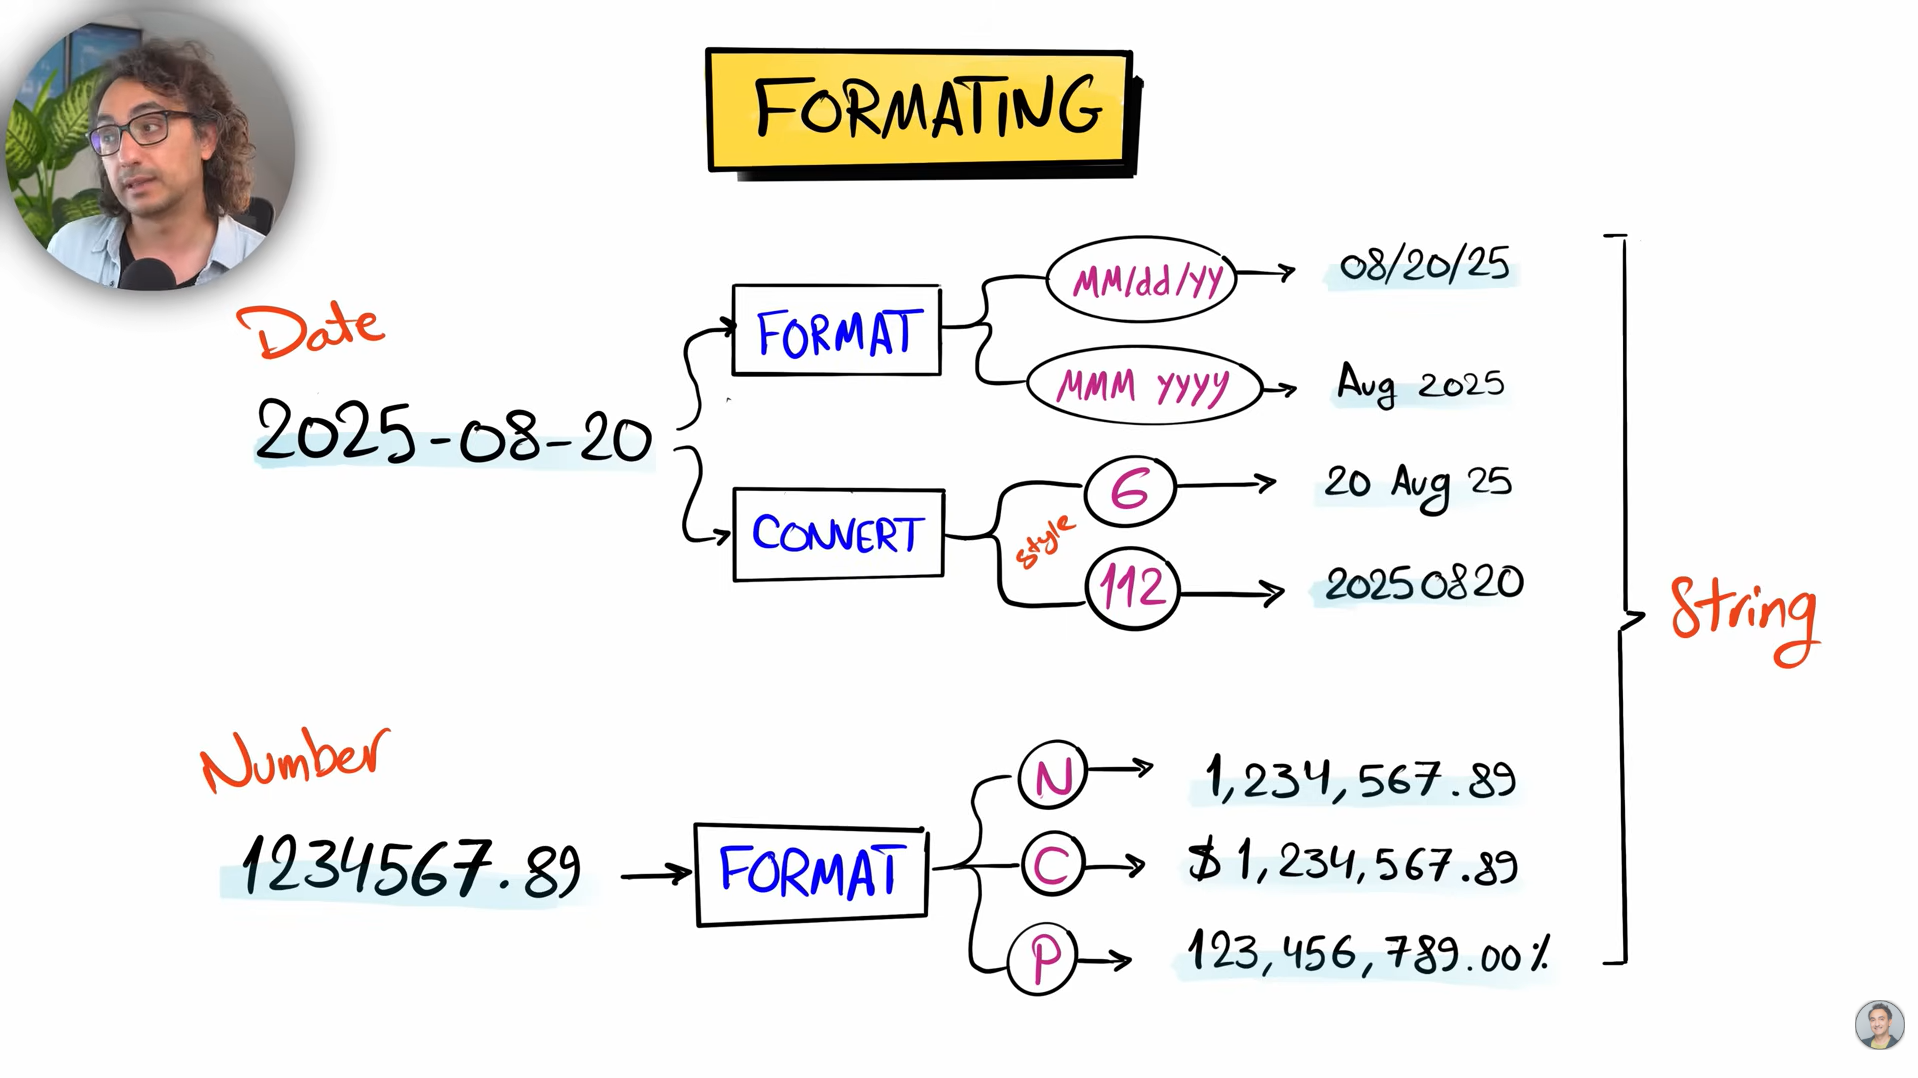

In [77]:
%%sql
select date_Format('2026-08-04', '%d') as Date,
    date_format('2026-08-24', '%m') as Month,
    date_format('2026-08-24', '%Y') as Year;

Running query in 'mysql+pymysql://'

1 rows affected.

Date,Month,Year
04,08,2026


In [79]:
%%sql
select date_Format('2026-08-04', '%W') as Day,
    date_format('2026-08-24', '%M') as Month,
    date_format('2026-08-24', '%Y') as Year;

Running query in 'mysql+pymysql://'

1 rows affected.

Day,Month,Year
Tuesday,August,2026


In [81]:
%%sql
select date_Format('2026-08-04', '%a') as Day,
    date_format('2026-08-24', '%b') as Month,
    date_format('2026-08-24', '%y') as Year;

Running query in 'mysql+pymysql://'

1 rows affected.

Day,Month,Year
Tue,Aug,26


In [82]:
%%sql
select orderid, creationtime, date_format(creationtime, '%m-%d-%Y') as USA, date_format(creationtime, '%d-%m-%Y') as EU from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,USA,EU
1,2025-01-01 12:34:56,01-01-2025,01-01-2025
2,2025-01-05 23:22:04,01-05-2025,05-01-2025
3,2025-01-10 18:24:08,01-10-2025,10-01-2025
4,2025-01-20 05:50:33,01-20-2025,20-01-2025
5,2025-02-01 14:02:41,02-01-2025,01-02-2025
6,2025-02-06 15:34:57,02-06-2025,06-02-2025
7,2025-02-16 06:22:01,02-16-2025,16-02-2025
8,2025-02-18 10:45:22,02-18-2025,18-02-2025
9,2025-03-10 12:59:04,03-10-2025,10-03-2025
10,2025-03-16 23:25:15,03-16-2025,16-03-2025


```
Show CREATIONTIME using the following format:
Day Wed Jan Q1 2025 12:34:56 PM
```

In [102]:
%%sql
select orderid, creationtime,
CONCAT (
    'Day', ' ',
    date_format(creationtime, '%a %b'), ' ', 
    'Q', QUARTER(creationtime), ' ',
    date_format(creationtime, '%y  %h:%i:%s %p')
) as Given_Date_Format
 from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,creationtime,Given_Date_Format
1,2025-01-01 12:34:56,Day Wed Jan Q1 25 12:34:56 PM
2,2025-01-05 23:22:04,Day Sun Jan Q1 25 11:22:04 PM
3,2025-01-10 18:24:08,Day Fri Jan Q1 25 06:24:08 PM
4,2025-01-20 05:50:33,Day Mon Jan Q1 25 05:50:33 AM
5,2025-02-01 14:02:41,Day Sat Feb Q1 25 02:02:41 PM
6,2025-02-06 15:34:57,Day Thu Feb Q1 25 03:34:57 PM
7,2025-02-16 06:22:01,Day Sun Feb Q1 25 06:22:01 AM
8,2025-02-18 10:45:22,Day Tue Feb Q1 25 10:45:22 AM
9,2025-03-10 12:59:04,Day Mon Mar Q1 25 12:59:04 PM
10,2025-03-16 23:25:15,Day Sun Mar Q1 25 11:25:15 PM


```
Report by Month year as Jan 25, ...
```

In [120]:
%%sql
select 
    Date_Format(creationtime, '%b-%y') as Month, 
    count(*) as Sales
from orders
group by Date_Format(creationtime, '%b-%y');

Running query in 'mysql+pymysql://'

3 rows affected.

Month,Sales
Jan-25,4
Feb-25,4
Mar-25,2


##### Number Formatting:

```
CODES:
-------------

N = Numeric Default   : FORMAT(1234.56, 2)
P = Percentage        : CONCAT(FORMAT(0.1234 * 100, 2), '%')
C = Currency          : CONCAT('$', FORMAT(1234.56, 2))
E = Scientific Notation
F = Fixed Point       : CAST(1234.56 AS DECIMAL(10,2))
N0 / N1 / N2 = Numeric no/one/two decimals
N, de_DE = Numeric (GERMAN)
N, en_US = Numeric (US)
```

Syntax:
FORMAT(Number, code)  -- for MSSQL ;           FORMAT(Number, code or digit)   -- MySQL


In [124]:
%%sql
select format('123', 2);

Running query in 'mysql+pymysql://'

1 rows affected.

"format('123', 2)"
123.00


##### CONVERT: Change the value to the different type / DataType

```
Syntax:
CONVERT(date_type, value, [, style])    -- where style is optional
MSSQL Flags:
1. INT
2. VARCHAR



CONVERT(value, data_type)    --- In MySQL
MySQL Flags:
1. BINARY
2. CHAR
3. DATE
4. DATETIME
5. TIME
6. DECIMAL(p,s)   p=total digit and s afterdecimal digits
7. SIGNED
8. UNSIGNED
9. JSON

In [131]:
%%sql
select convert('123000', time) as `Converted Time`;

Running query in 'mysql+pymysql://'

1 rows affected.

Converted Time
12:30:00


In [136]:
%%sql
select creationtime, convert(creationtime, date) as `Date from CreationTime`, 
DATE_FORMAT(creationtime, '%d-%b-%Y') as `Formatted Date`
 from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

creationtime,Date from CreationTime,Formatted Date
2025-01-01 12:34:56,2025-01-01,01-Jan-2025
2025-01-05 23:22:04,2025-01-05,05-Jan-2025
2025-01-10 18:24:08,2025-01-10,10-Jan-2025
2025-01-20 05:50:33,2025-01-20,20-Jan-2025
2025-02-01 14:02:41,2025-02-01,01-Feb-2025
2025-02-06 15:34:57,2025-02-06,06-Feb-2025
2025-02-16 06:22:01,2025-02-16,16-Feb-2025
2025-02-18 10:45:22,2025-02-18,18-Feb-2025
2025-03-10 12:59:04,2025-03-10,10-Mar-2025
2025-03-16 23:25:15,2025-03-16,16-Mar-2025


##### CAST() : Converts value to a specific data type

```
CASTING : Changing the data type from one to another

Syntax:
MSSQL : CAST(value as data_type)
MySQL : CAST(value as data_type)
```

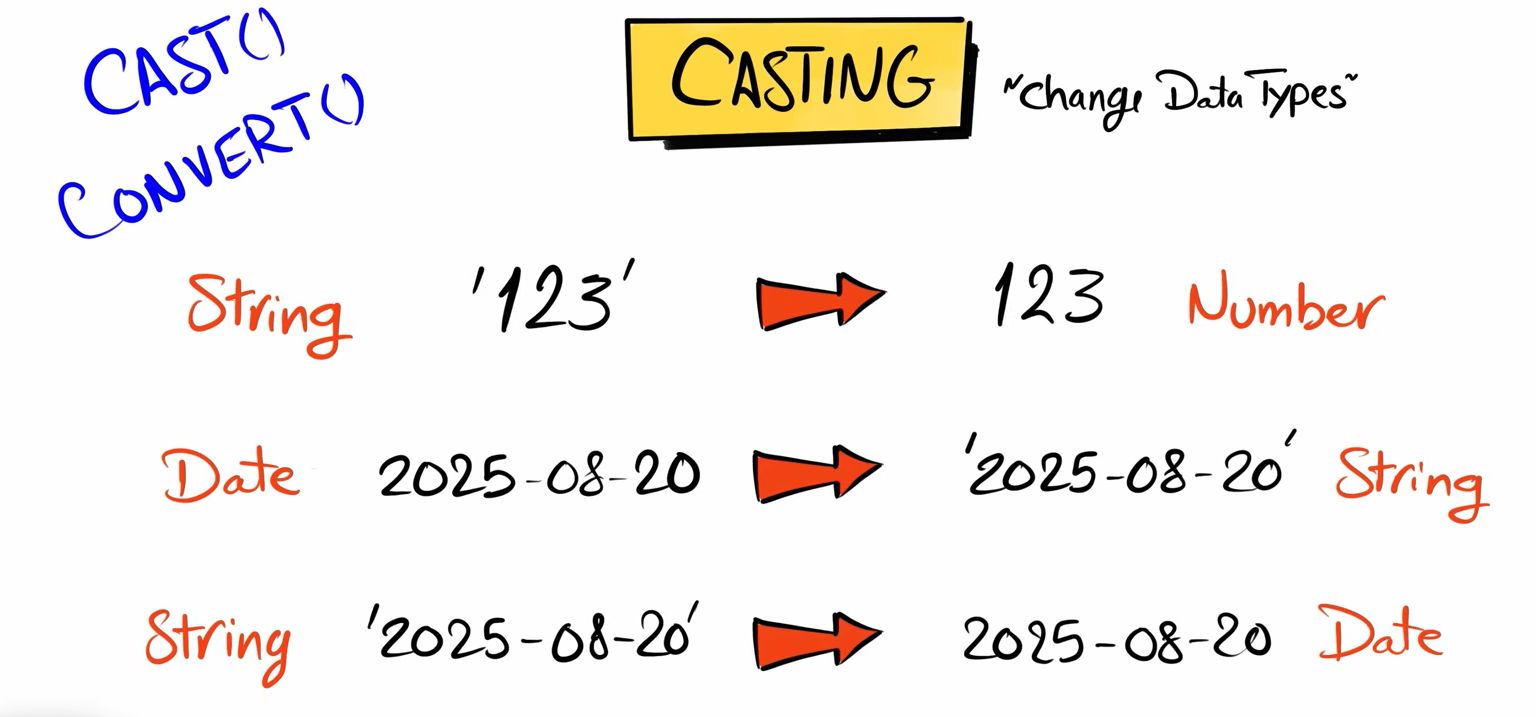

In [11]:
%%sql
select cast('123' as signed) as `Casted INT`,
    cast('20260802' as date) as `Casted DATE`,
    cast(123 as char) as `Casted CHAR`,
    cast(20260804 as Datetime) as `Catsed DateTime`;

Running query in 'mysql+pymysql://'

1 rows affected.

Casted INT,Casted DATE,Casted CHAR,Catsed DateTime
123,2026-08-02,123,2026-08-04 00:00:00


In [12]:
%%sql
select creationtime, cast(creationtime as date) as `Date` from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

creationtime,Date
2025-01-01 12:34:56,2025-01-01
2025-01-05 23:22:04,2025-01-05
2025-01-10 18:24:08,2025-01-10
2025-01-20 05:50:33,2025-01-20
2025-02-01 14:02:41,2025-02-01
2025-02-06 15:34:57,2025-02-06
2025-02-16 06:22:01,2025-02-16
2025-02-18 10:45:22,2025-02-18
2025-03-10 12:59:04,2025-03-10
2025-03-16 23:25:15,2025-03-16


#### Calculation on Dates : (DATE_ADD, DATEADD, DATEDIFF)

##### DATE_ADD() / DATEADD() : Adds or subtracts a specific time interval to/from a date.

```
Syntax:
DATEADD(part, interval, date)
DATE_ADD(date, INTERVAL add_sub_vale unit_as_DAY_MONTH)
```

In [18]:
%%sql
select now() as `Current TimeStamp`,
    date_add(now(), INTERVAL + 2 YEAR) as `Added Date`,
    date_add(now(), INTERVAL -5 HOUR) as `Subtracted Hour`;

Running query in 'mysql+pymysql://'

1 rows affected.

Current TimeStamp,Added Date,Subtracted Hour
2026-07-15 19:16:43,2028-07-15 19:16:43,2026-07-15 14:16:43


In [24]:
%%sql
select date(now()) as `Date`,
    date_add(date(now()), INTERVAL +1 YEAR) as `Added Year`,
    date_add(date(now()), INTERVAL -1 YEAR) as `Subtracted Year`,
    date_add(date(now()), INTERVAL +2 MONTH) as `Added Month`,
    date_add(date(now()), INTERVAL -2 MONTH) as `Subtracted Month`,
    date_add(date(now()), INTERVAL +3 DAY) as `Added Date`,
    date_add(date(now()), INTERVAL -3 DAY) as `Subtracted Date`;

Running query in 'mysql+pymysql://'

1 rows affected.

Date,Added Year,Subtracted Year,Added Month,Subtracted Month,Added Date,Subtracted Date
2026-07-15,2027-07-15,2025-07-15,2026-09-15,2026-05-15,2026-07-18,2026-07-12


In [45]:
%%sql
select creationtime,
    date_add(creationtime, INTERVAL 2 YEAR) as `Two Years Added TimeStamp`,
    date_add(creationtime, INTERVAL '2-3' YEAR_MONTH) as `Two Years + Three Months Added TimeStamp`,
    date_add(date_add(creationtime, INTERVAL '2-3' YEAR_MONTH), INTERVAL 5 DAY) as `Two Years + Three Months + 5 Days Addded`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

creationtime,Two Years Added TimeStamp,Two Years + Three Months Added TimeStamp,Two Years + Three Months + 5 Days Addded
2025-01-01 12:34:56,2027-01-01 12:34:56,2027-04-01 12:34:56,2027-04-06 12:34:56
2025-01-05 23:22:04,2027-01-05 23:22:04,2027-04-05 23:22:04,2027-04-10 23:22:04
2025-01-10 18:24:08,2027-01-10 18:24:08,2027-04-10 18:24:08,2027-04-15 18:24:08
2025-01-20 05:50:33,2027-01-20 05:50:33,2027-04-20 05:50:33,2027-04-25 05:50:33
2025-02-01 14:02:41,2027-02-01 14:02:41,2027-05-01 14:02:41,2027-05-06 14:02:41
2025-02-06 15:34:57,2027-02-06 15:34:57,2027-05-06 15:34:57,2027-05-11 15:34:57
2025-02-16 06:22:01,2027-02-16 06:22:01,2027-05-16 06:22:01,2027-05-21 06:22:01
2025-02-18 10:45:22,2027-02-18 10:45:22,2027-05-18 10:45:22,2027-05-23 10:45:22
2025-03-10 12:59:04,2027-03-10 12:59:04,2027-06-10 12:59:04,2027-06-15 12:59:04
2025-03-16 23:25:15,2027-03-16 23:25:15,2027-06-16 23:25:15,2027-06-21 23:25:15


##### DATEDIFF() : returns the date diffrenece between two dates in Days

```
Syntax :
MSSQL : DATEDIFF(part, start_date, end_date)
MySQL : DATEDIFF(start_date, end_date)
```

In [54]:
%%sql
select DATEDIFF('2026-08-24', '2026-08-06') as `Date Difference as Days`;

Running query in 'mysql+pymysql://'

1 rows affected.

Date Difference as Days
18


##### TIMESTAMPDIFF : Similart to DATEDIFF in MSSQL

In [4]:
%%sql
select '2028-08-02' as Start_Date,
    '2030-08-03' as End_Date,
    timestampdiff(year, '2028-08-02', '2030-08-03') as `Year Differnce`,
    timestampdiff(month, '2028-08-02', '2030-08-03') as `Month Differnce`,
    timestampdiff(day, '2028-08-02', '2030-08-03') as `Day Differnce`,
    timestampdiff(hour, '2028-08-02', '2030-08-03') as `Hour Differnce`;

Running query in 'mysql+pymysql://'

1 rows affected.

Start_Date,End_Date,Year Differnce,Month Differnce,Day Differnce,Hour Differnce
2028-08-02,2030-08-03,2,24,731,17544


Calculate the age of the Employees.

In [6]:
%%sql
select * from employees;

Running query in 'mysql+pymysql://'

5 rows affected.

employeeid,firstname,lastname,department,birthdate,gender,salary,managerid
1,Frank,Lee,Marketing,1988-12-05,M,55000,None
2,Kevin,Brown,Marketing,1972-11-25,M,65000,1
3,Mary,None,Sales,1986-01-05,F,75000,1
4,Michael,Ray,Sales,1977-02-10,M,90000,2
5,Carol,Baker,Sales,1982-02-11,F,55000,3


In [24]:
%%sql
select concat_ws(' ', firstname, lastname) as `Employee Name`,
    timestampdiff(year, birthdate, '2025-01-01') as Age
from employees;

Running query in 'mysql+pymysql://'

5 rows affected.

Employee Name,Age
Frank Lee,36
Kevin Brown,52
Mary,38
Michael Ray,47
Carol Baker,42


In [23]:
%%sql
select concat_ws(' ', firstname, lastname) as `Employee Name`,
    timestampdiff(year, birthdate, now()) as Age
from employees;

Running query in 'mysql+pymysql://'

5 rows affected.

Employee Name,Age
Frank Lee,37
Kevin Brown,53
Mary,40
Michael Ray,49
Carol Baker,44


Find the average shipping duration in days for each month.

In [25]:
%%sql
select * from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,customerid,salespersonid,orderdate,shipdate,orderstatus,shipaddress,billaddress,quantity,sales,creationtime
1,101,2,3,2025-01-01,2025-01-05,Delivered,9833 Mt. Dias Blv.,1226 Shoe St.,1,10,2025-01-01 12:34:56
2,102,3,3,2025-01-05,2025-01-10,Shipped,250 Race Court,None,1,15,2025-01-05 23:22:04
3,101,1,5,2025-01-10,2025-01-25,Delivered,8157 W. Book,8157 W. Book,2,20,2025-01-10 18:24:08
4,105,1,3,2025-01-20,2025-01-25,Shipped,5724 Victory Lane,,2,60,2025-01-20 05:50:33
5,104,2,5,2025-02-01,2025-02-05,Delivered,None,None,1,25,2025-02-01 14:02:41
6,104,3,5,2025-02-05,2025-02-10,Delivered,1792 Belmont Rd.,None,2,50,2025-02-06 15:34:57
7,102,1,1,2025-02-15,2025-02-27,Delivered,136 Balboa Court,,2,30,2025-02-16 06:22:01
8,101,4,3,2025-02-18,2025-02-27,Shipped,2947 Vine Lane,4311 Clay Rd,3,90,2025-02-18 10:45:22
9,101,2,3,2025-03-10,2025-03-15,Shipped,3768 Door Way,,2,20,2025-03-10 12:59:04
10,102,3,5,2025-03-15,2025-03-20,Shipped,None,None,0,60,2025-03-16 23:25:15


In [37]:
%%sql
select 
    monthname(shipdate) as Month,
    avg(timestampdiff(day, orderdate, shipdate)) as `Monthly Shipping Day AVG`
from orders group by Monthname(shipdate);

Running query in 'mysql+pymysql://'

3 rows affected.

Month,Monthly Shipping Day AVG
January,7.2500
February,7.5000
March,5.0000


```
LAG(columnname) OVER(ORDER BY columnname) : Returns just previous record
```

Find the number of days between each order and the previous order

In [47]:
%%sql
select orderid,
    orderdate as `Current Order Date`,
    LAG(orderdate) over(
        order by orderdate
    ) as `Previous Order Date`,
    Timestampdiff(
        day,
        LAG(orderdate) over(
            order by orderdate
        ),
        orderdate
    ) as `Day Difference`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,Current Order Date,Previous Order Date,Day Difference
1,2025-01-01,None,None
2,2025-01-05,2025-01-01,4
3,2025-01-10,2025-01-05,5
4,2025-01-20,2025-01-10,10
5,2025-02-01,2025-01-20,12
6,2025-02-05,2025-02-01,4
7,2025-02-15,2025-02-05,10
8,2025-02-18,2025-02-15,3
9,2025-03-10,2025-02-18,20
10,2025-03-15,2025-03-10,5


#### Date Validation : ISDATE : Only return boolean value either TRUE or FALSE

```
Syntax:

MSSQL - ISDATE(value) --> T or F
MySQL - SELECT IF(STR_TO_DATE(value, format) IS NOT NULL, 1, 0) as IS_VALID_DATE
```

In [61]:
%%sql
select if(str_to_date('2026/07/09', '%Y%m%d') IS NOT NULL, 1, 0) as is_valid_date;

Running query in 'mysql+pymysql://'

1 rows affected.

is_valid_date
0


In [66]:
%%sql
SELECT IF(STR_TO_DATE('20240525', '%Y%m%d') IS NOT NULL, 1, 0) as IS_VALID_DATE;

Running query in 'mysql+pymysql://'

1 rows affected.

IS_VALID_DATE
1


In [72]:
%%sql
select 
if(str_to_date(20240809, '%Y%m%d') is not null, 1, 0) as Datecheck1,
if(str_to_date('2024-08-09', '%Y-%m-%d') is not null, 1, 0) as Datecheck2,
if(str_to_date(20240839, '%Y%m%d') is not null, 1, 0) as Datecheck3;

Running query in 'mysql+pymysql://'

1 rows affected.

Datecheck1,Datecheck2,Datecheck3
1,1,0


## NULL FUNCTION : NULL means NOTHING, UNKNOWN

```
NULL is not equal to anything
NULL is not a zero
NULL is not an empty string
NULL is not blank space
```

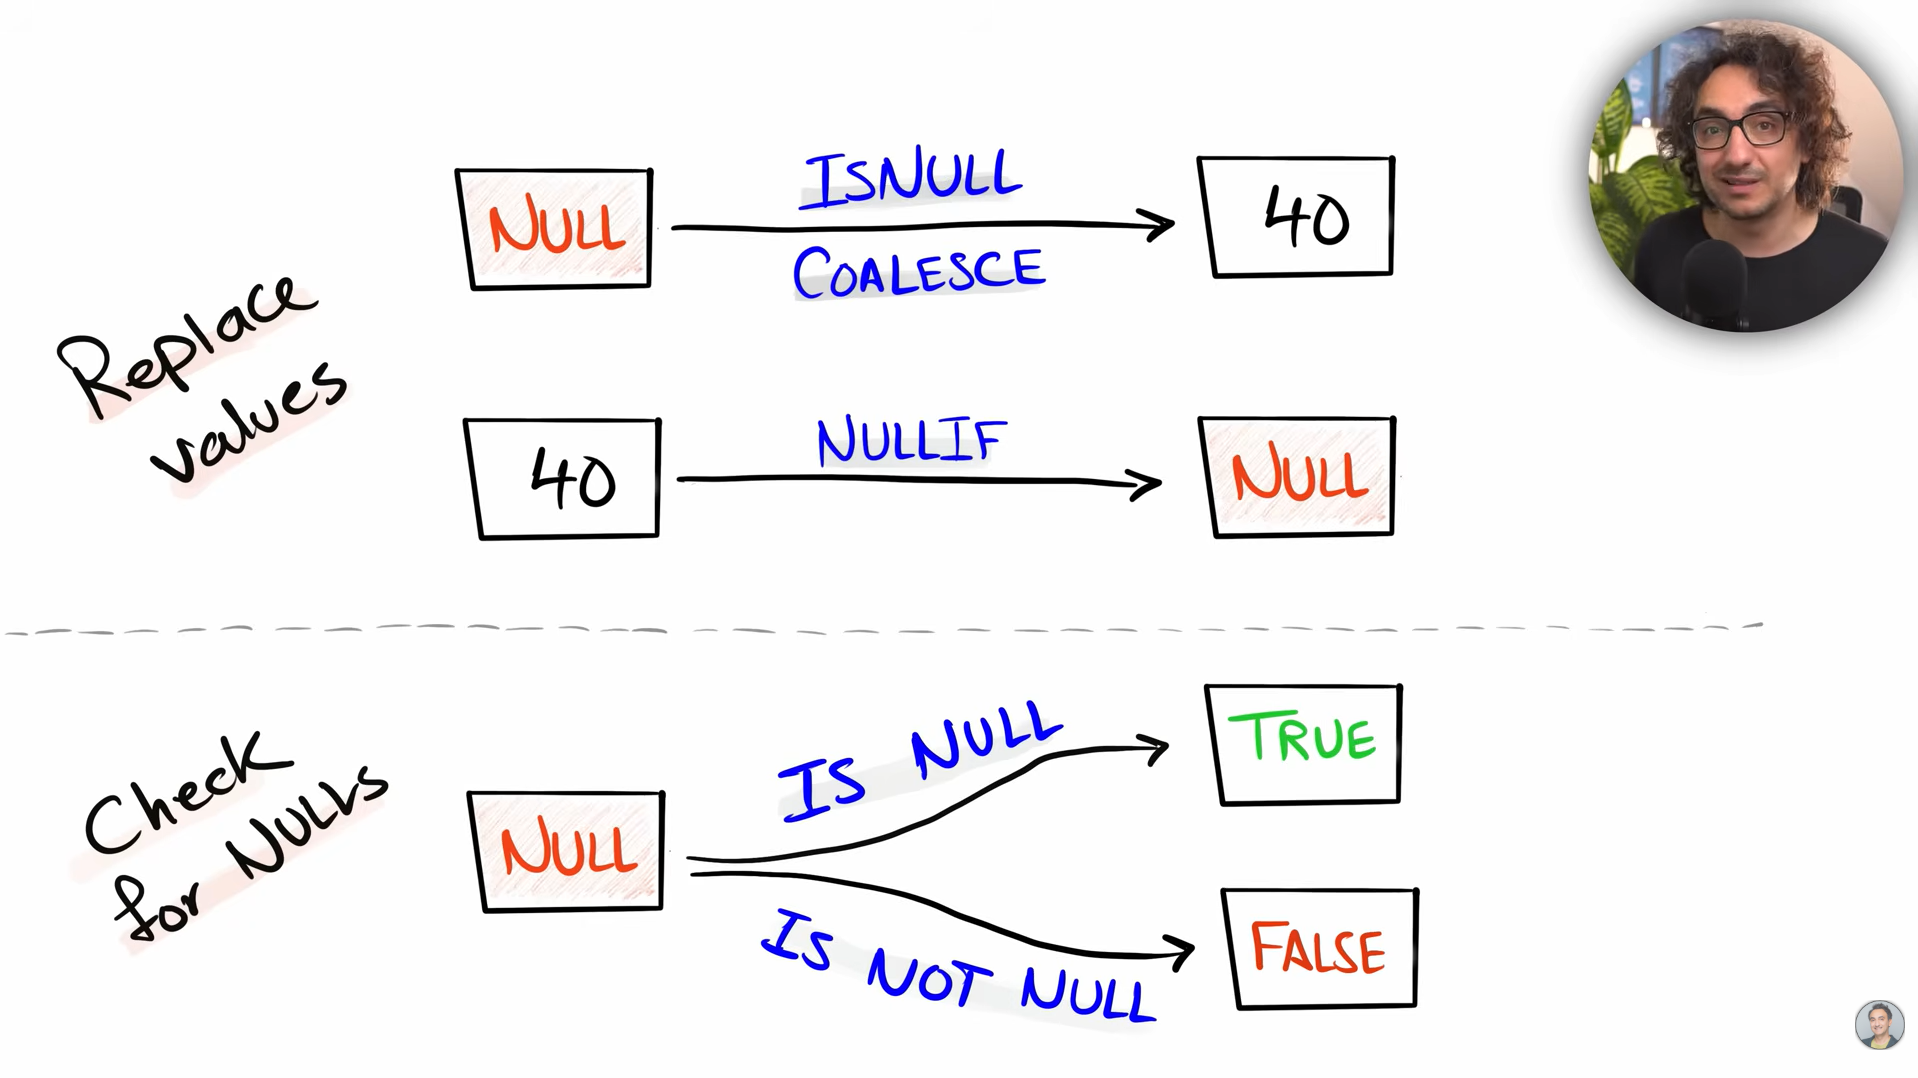

### ISNULL : Replaces NULL with a specified value

```
Syntax : 
MSSQL - ISNULL(value, replacement_value)
MySQL - IFNULL(value, replacement_value)
```

In [84]:
%%sql
select *from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

customerid,firstname,lastname,country,score
1,Jossef,Goldberg,Germany,350
2,Kevin,Brown,USA,900
3,Mary,None,USA,750
4,Mark,Schwarz,Germany,500
5,Anna,Adams,USA,None


In [92]:
%%sql
select *, IFNULL(lastname, ' ') as `IFNULL` from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

customerid,firstname,lastname,country,score,IFNULL
1,Jossef,Goldberg,Germany,350,Goldberg
2,Kevin,Brown,USA,900,Brown
3,Mary,None,USA,750,
4,Mark,Schwarz,Germany,500,Schwarz
5,Anna,Adams,USA,None,Adams


In [93]:
%%sql
select customerid, firstname, IFNULL(lastname, ' ') as `lastname`, country, score from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

customerid,firstname,lastname,country,score
1,Jossef,Goldberg,Germany,350
2,Kevin,Brown,USA,900
3,Mary,,USA,750
4,Mark,Schwarz,Germany,500
5,Anna,Adams,USA,None


In [101]:
%%sql
select orderid, shipaddress, billaddress, IFNULL(shipaddress, IFNULL(billaddress, 'UKNOWN')) as `Updated ShipAddress` from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,shipaddress,billaddress,Updated ShipAddress
1,9833 Mt. Dias Blv.,1226 Shoe St.,9833 Mt. Dias Blv.
2,250 Race Court,None,250 Race Court
3,8157 W. Book,8157 W. Book,8157 W. Book
4,5724 Victory Lane,,5724 Victory Lane
5,None,None,UKNOWN
6,1792 Belmont Rd.,None,1792 Belmont Rd.
7,136 Balboa Court,,136 Balboa Court
8,2947 Vine Lane,4311 Clay Rd,2947 Vine Lane
9,3768 Door Way,,3768 Door Way
10,None,None,UKNOWN


### COALESCE() : Returns first non-NULL value from list

```
Syntax :

COALESCE(value1, value2, value3, ....., valueN)
```

In [102]:
%%sql
select orderid, shipaddress, billaddress from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,shipaddress,billaddress
1,9833 Mt. Dias Blv.,1226 Shoe St.
2,250 Race Court,None
3,8157 W. Book,8157 W. Book
4,5724 Victory Lane,
5,None,None
6,1792 Belmont Rd.,None
7,136 Balboa Court,
8,2947 Vine Lane,4311 Clay Rd
9,3768 Door Way,
10,None,None


In [105]:
%%sql
select orderid, shipaddress, billaddress, coalesce(shipaddress, billaddress, 'UNKOWN') as `Updated ShipAddress` from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,shipaddress,billaddress,Updated ShipAddress
1,9833 Mt. Dias Blv.,1226 Shoe St.,9833 Mt. Dias Blv.
2,250 Race Court,None,250 Race Court
3,8157 W. Book,8157 W. Book,8157 W. Book
4,5724 Victory Lane,,5724 Victory Lane
5,None,None,UNKOWN
6,1792 Belmont Rd.,None,1792 Belmont Rd.
7,136 Balboa Court,,136 Balboa Court
8,2947 Vine Lane,4311 Clay Rd,2947 Vine Lane
9,3768 Door Way,,3768 Door Way
10,None,None,UNKOWN


### ISNULL/ IFNULL V/S COALESCE:

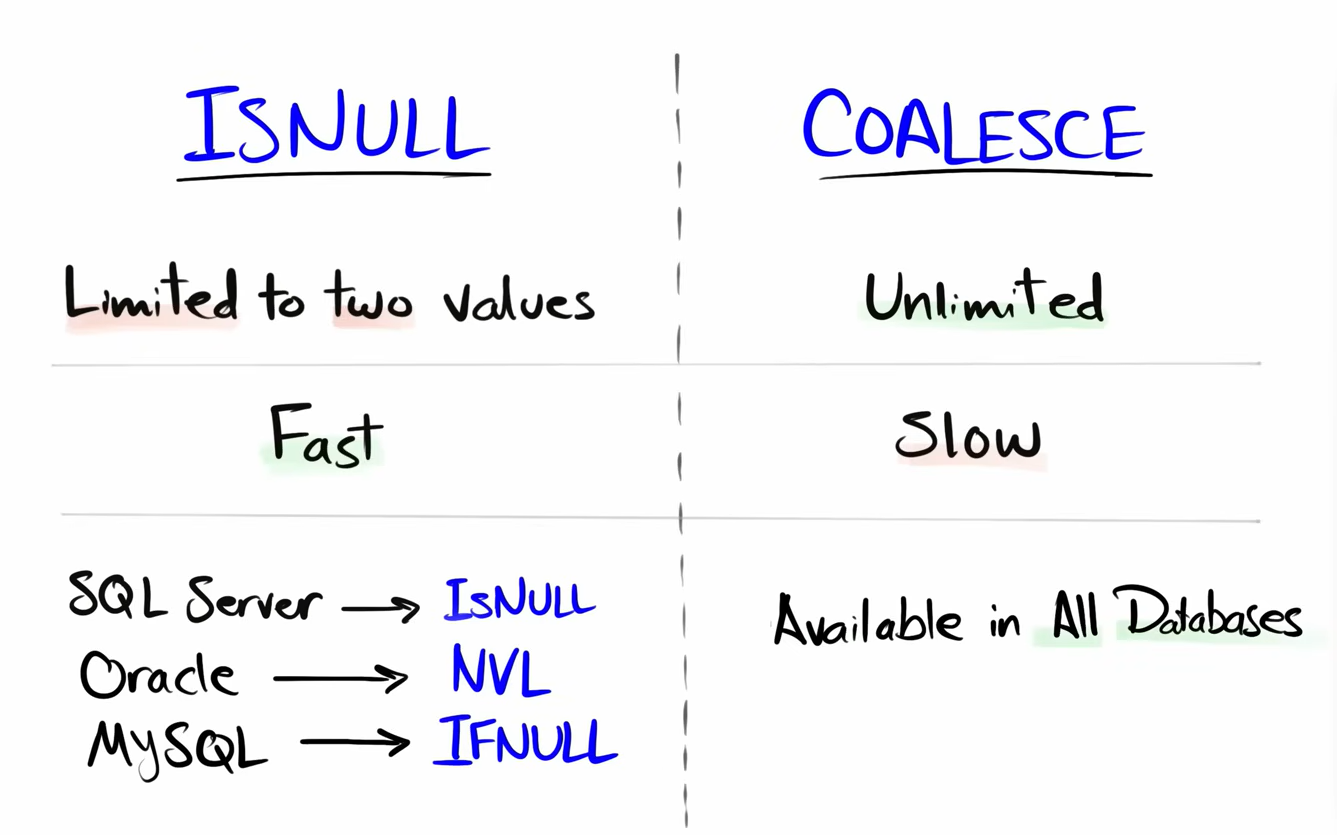

### USECAESES : 

#### Find the average scores of the Customers.

In [106]:
%%sql
select * from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

customerid,firstname,lastname,country,score
1,Jossef,Goldberg,Germany,350
2,Kevin,Brown,USA,900
3,Mary,None,USA,750
4,Mark,Schwarz,Germany,500
5,Anna,Adams,USA,None


In [107]:
%%sql
select avg(score) from customers;

Running query in 'mysql+pymysql://'

1 rows affected.

avg(score)
625.0000


In [118]:
%%sql
select round(avg(score), 0) as `InCorrect AVG_Score`, round(avg(coalesce(score, 0)), 0) as Correct_AVG_Score
from customers;

Running query in 'mysql+pymysql://'

1 rows affected.

InCorrect AVG_Score,Correct_AVG_Score
625,500


#### Display the Full Name of the cutomers in a single column by merging their firstname and lastname and ADD 10 bonus points to each customer's score

In [127]:
%%sql
select concat(
        coalesce(firstname, ''),
        ' ',
        coalesce(lastname, '')
    ) as Full_Name,
    (coalesce(score, 0) + 10) as `Score + 10`
from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

Full_Name,Score + 10
Jossef Goldberg,360
Kevin Brown,910
Mary,760
Mark Schwarz,510
Anna Adams,10


#### Sort the customers from lowest to highest scores, with NULL appearing in last

In [132]:
%%sql
Select *
from customers
ORDER BY CASE
        WHEN Score IS NULL THEN 1
        ELSE 0
    END,
    score;

Running query in 'mysql+pymysql://'

5 rows affected.

customerid,firstname,lastname,country,score
1,Jossef,Goldberg,Germany,350
4,Mark,Schwarz,Germany,500
3,Mary,None,USA,750
2,Kevin,Brown,USA,900
5,Anna,Adams,USA,None


### NULLIF() : 
```
Compares two expressions and returns:
    - NULL --> if they are equal
    - First Value --> if they are not equal
```

In [133]:
%%sql
select * from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

customerid,firstname,lastname,country,score
1,Jossef,Goldberg,Germany,350
2,Kevin,Brown,USA,900
3,Mary,None,USA,750
4,Mark,Schwarz,Germany,500
5,Anna,Adams,USA,None


In [142]:
%%sql
select customerid, lastname, NULLIF(COALESCE(lastname, 'N/A'), 'Goldberg') as `NULLIF` from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

customerid,lastname,NULLIF
1,Goldberg,None
2,Brown,Brown
3,None,N/A
4,Schwarz,Schwarz
5,Adams,Adams


##### Division by Zero Case:

Find the sales price for each order by dividing the sales by the quantity.

In [152]:
%%sql
select orderid, productid, quantity, sales, round((sales/NULLIF(quantity, 0)), 1) as sales_price from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,quantity,sales,sales_price
1,101,1,10,10.0
2,102,1,15,15.0
3,101,2,20,10.0
4,105,2,60,30.0
5,104,1,25,25.0
6,104,2,50,25.0
7,102,2,30,15.0
8,101,3,90,30.0
9,101,2,20,10.0
10,102,0,60,None


### IS NULL : Returns TRUE if the value is NULL, otherwise FALSE

```
Syntax :
colmnName/value IS NULL
```

In [162]:
%%sql
SELECT IF(NULL IS NULL, 'TRUE', 'FALSE') AS `IS NULL`;

Running query in 'mysql+pymysql://'

1 rows affected.

IS NULL
TRUE


In [163]:
%%sql
SELECT IF(23 IS NULL, 'TRUE', 'FALSE') AS `IS NULL`;

Running query in 'mysql+pymysql://'

1 rows affected.

IS NULL
FALSE


In [164]:
%%sql
SELECT IF('SQL' IS NULL, 'TRUE', 'FALSE') AS `IS NULL`;

Running query in 'mysql+pymysql://'

1 rows affected.

IS NULL
FALSE


In [165]:
%%sql
SELECT IF(NOT NULL IS NULL, 'TRUE', 'FALSE') AS `IS NULL`;

Running query in 'mysql+pymysql://'

1 rows affected.

IS NULL
FALSE


### IS NOT NULL : Returns TRUE if the value is NOT NULL, otherwise FALSE

```
Syntax :
colmnName/value IS NOT NULL
```

In [167]:
%%sql
SELECT IF(NULL IS NOT NULL, 'TRUE', 'FALSE') AS `IS NULL`;

Running query in 'mysql+pymysql://'

1 rows affected.

IS NULL
FALSE


In [168]:
%%sql
SELECT IF(23 IS NOT NULL, 'TRUE', 'FALSE') AS `IS NULL`;

Running query in 'mysql+pymysql://'

1 rows affected.

IS NULL
TRUE


In [169]:
%%sql
SELECT IF('SQL' IS NOT NULL, 'TRUE', 'FALSE') AS `IS NULL`;

Running query in 'mysql+pymysql://'

1 rows affected.

IS NULL
TRUE


In [170]:
%%sql
SELECT IF(NOT NULL IS NOT NULL, 'TRUE', 'FALSE') AS `IS NULL`;

Running query in 'mysql+pymysql://'

1 rows affected.

IS NULL
TRUE


In [1]:
%%sql
use salesdb;

Running query in 'mysql+pymysql://'

++
||
++
++

In [76]:
%%sql
select orderdate,
    shipdate,
    creationtime
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderdate,shipdate,creationtime
2025-01-01,2025-01-05,2025-01-01 12:34:56
2025-01-05,2025-01-10,2025-01-05 23:22:04
2025-01-10,2025-01-25,2025-01-10 18:24:08
2025-01-20,2025-01-25,2025-01-20 05:50:33
2025-02-01,2025-02-05,2025-02-01 14:02:41
2025-02-05,2025-02-10,2025-02-06 15:34:57
2025-02-15,2025-02-27,2025-02-16 06:22:01
2025-02-18,2025-02-27,2025-02-18 10:45:22
2025-03-10,2025-03-15,2025-03-10 12:59:04
2025-03-15,2025-03-20,2025-03-16 23:25:15


####